In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("AQI_dataset.csv")

# Preview
print(df.head())
print(df.shape)

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
(29531, 16)


In [ ]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Sort by date
df = df.sort_values(by='Date')


In [ ]:
# Filter only Chennai data
df = df[df['City'] == 'Chennai']

print("After filtering Chennai:", df.shape)


After filtering Chennai: (2009, 16)


In [ ]:
df = df[['Date','PM2.5','PM10','NO2','SO2','CO','O3','NH3']]


In [ ]:
print(df.isnull().sum())


Date        0
PM2.5     117
PM10     1707
NO2        36
SO2        36
CO         25
O3         49
NH3       462
dtype: int64


In [ ]:
df = df.fillna(method='ffill')
df = df.fillna(method='bfill')


/tmp/ipython-input-73320661.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipython-input-73320661.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


In [ ]:
df.set_index('Date', inplace=True)


In [ ]:
df = df.resample('D').mean()


In [ ]:
print(df.head())
print(df.tail())
print(df.isnull().sum())


             PM2.5   PM10    NO2    SO2    CO     O3   NH3
Date                                                      
2015-01-01  173.51  48.55  15.39   9.20  1.17  11.35  4.59
2015-01-02  173.51  48.55  13.42   8.61  1.23   9.16  7.83
2015-01-03  173.51  48.55  19.56  48.23  0.77  13.45  4.63
2015-01-04  173.51  48.55  16.20  27.96  1.00  10.33  5.23
2015-01-05  173.51  48.55  16.30  16.60  0.90   9.36  5.50
            PM2.5   PM10    NO2   SO2    CO     O3    NH3
Date                                                     
2020-06-27  26.42  39.30  12.96  7.29  1.10  68.51  33.20
2020-06-28  25.93  45.54  10.00  6.48  0.76  77.45  35.98
2020-06-29  21.30  22.21   9.69  6.62  0.96  62.57  34.07
2020-06-30  24.14  30.66  12.38  7.50  1.05  68.75  34.17
2020-07-01  15.95   4.85  10.72  9.23  1.02  48.37  33.52
PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
NH3      0
dtype: int64


In [ ]:
df.to_csv("clean_chennai_multivariate_aqi.csv")
print("Clean dataset saved successfully!")


Clean dataset saved successfully!


In [ ]:
df = pd.read_csv("clean_chennai_multivariate_aqi.csv", index_col='Date', parse_dates=True)

print(df.head())

             PM2.5   PM10    NO2    SO2    CO     O3   NH3
Date                                                      
2015-01-01  173.51  48.55  15.39   9.20  1.17  11.35  4.59
2015-01-02  173.51  48.55  13.42   8.61  1.23   9.16  7.83
2015-01-03  173.51  48.55  19.56  48.23  0.77  13.45  4.63
2015-01-04  173.51  48.55  16.20  27.96  1.00  10.33  5.23
2015-01-05  173.51  48.55  16.30  16.60  0.90   9.36  5.50


In [ ]:
# target column
target = df['PM2.5']

# feature columns
features = df[['PM2.5','PM10','NO2','SO2','CO','O3','NH3']]


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_data, columns=features.columns, index=features.index)

print(scaled_df.head())


               PM2.5      PM10       NO2       SO2        CO        O3  \
Date                                                                     
2015-01-01  0.581985  0.139501  0.107406  0.167137  0.056741  0.092422   
2015-01-02  0.581985  0.139501  0.089259  0.155242  0.059651  0.071228   
2015-01-03  0.581985  0.139501  0.145818  0.954032  0.037342  0.112746   
2015-01-04  0.581985  0.139501  0.114867  0.545363  0.048497  0.082551   
2015-01-05  0.581985  0.139501  0.115789  0.316331  0.043647  0.073164   

                 NH3  
Date                  
2015-01-01  0.012951  
2015-01-02  0.022133  
2015-01-03  0.013064  
2015-01-04  0.014765  
2015-01-05  0.015530  


In [ ]:
training_size = int(len(scaled_df) * 0.8)

train_data = scaled_df[:training_size]
test_data = scaled_df[training_size:]

print(train_data.shape, test_data.shape)


(1607, 7) (402, 7)


In [ ]:
#Day1-Day30 → predict Day31 PM2.5
#Day2-Day31 → predict Day32 PM2.5


In [ ]:
def create_sequences(data, time_steps=30):
    X = []
    y = []

    for i in range(len(data) - time_steps):
        X.append(data.iloc[i:i+time_steps].values)
        y.append(data.iloc[i+time_steps]['PM2.5'])  # target = next day PM2.5

    return np.array(X), np.array(y)


In [ ]:
time_steps = 30

X_train, y_train = create_sequences(train_data, time_steps)
X_test, y_test = create_sequences(test_data, time_steps)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (1577, 30, 7)
y_train shape: (1577,)


In [ ]:
import joblib
joblib.dump(scaler, "aqi_scaler.pkl")


['aqi_scaler.pkl']

In [ ]:
#X_train → (samples, 30 days, 7 pollutants)
#y_train → (next day PM2.5)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
model = Sequential()

# First LSTM layer
model.add(LSTM(64, return_sequences=True, input_shape=(30,7)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))

# Fully connected layer
model.add(Dense(25, activation='relu'))

# Output layer (predict PM2.5)
model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0213 - val_loss: 0.0055
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0076 - val_loss: 0.0049
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0067 - val_loss: 0.0047
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0068 - val_loss: 0.0040
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0081 - val_loss: 0.0049
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0081 - val_loss: 0.0051
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0070 - val_loss: 0.0039
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0061 - val_loss: 0.0038
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0066 - val_loss: 0.0040
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0074 - val_loss: 0.0041
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0078 - val_loss: 0.0043
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0

In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,323 (622.36 KB)

 Trainable params: 53,107 (207.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 106,216 (414.91 KB)

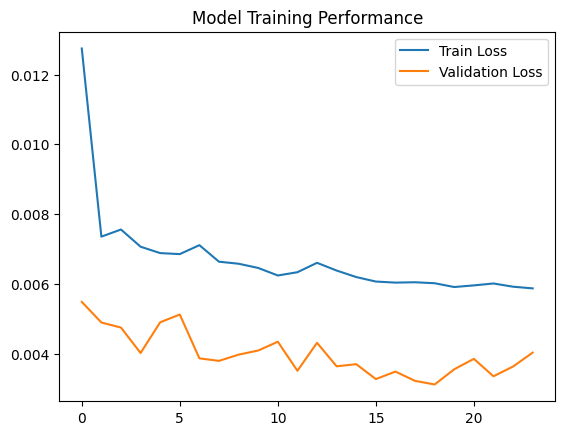

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Training Performance")
plt.show()


In [ ]:
model.save("aqi_lstm_model.h5")
